In [19]:
import os
os.chdir("..")

In [20]:
from data.data import build_byol_transforms, ssl_ds, build_galaxy_aware_transforms
import torch
import matplotlib.pyplot as plt
import numpy as np

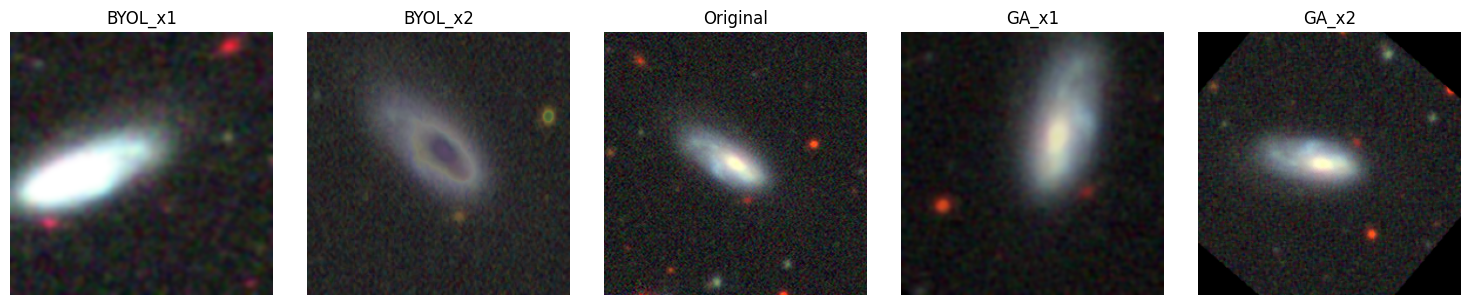

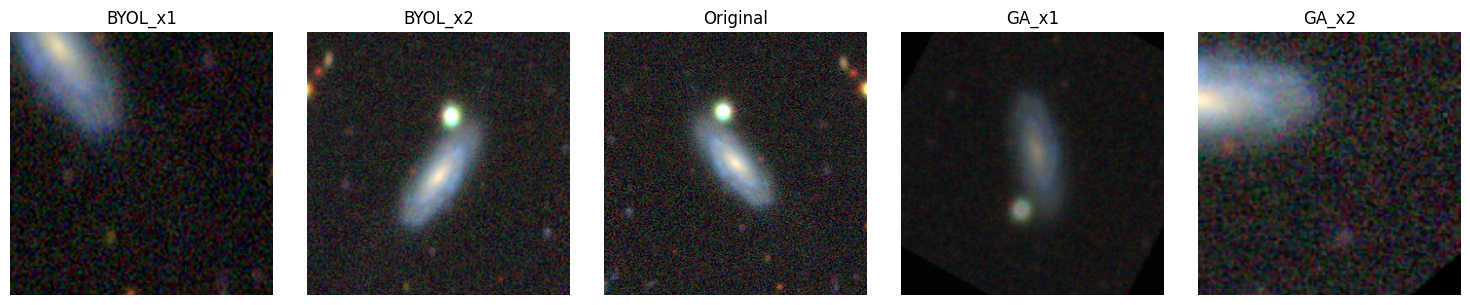

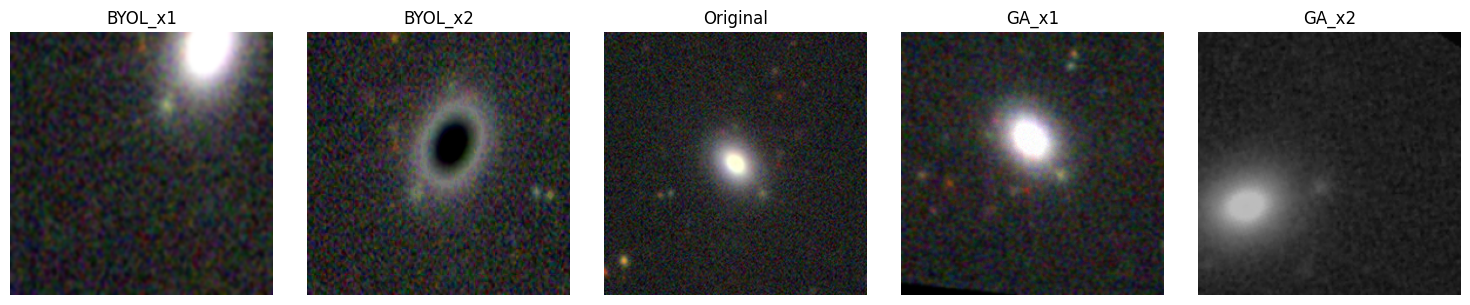

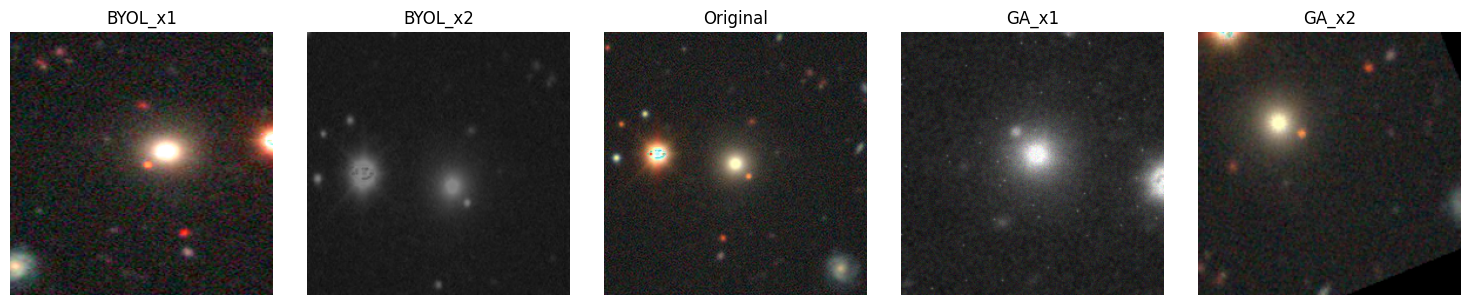

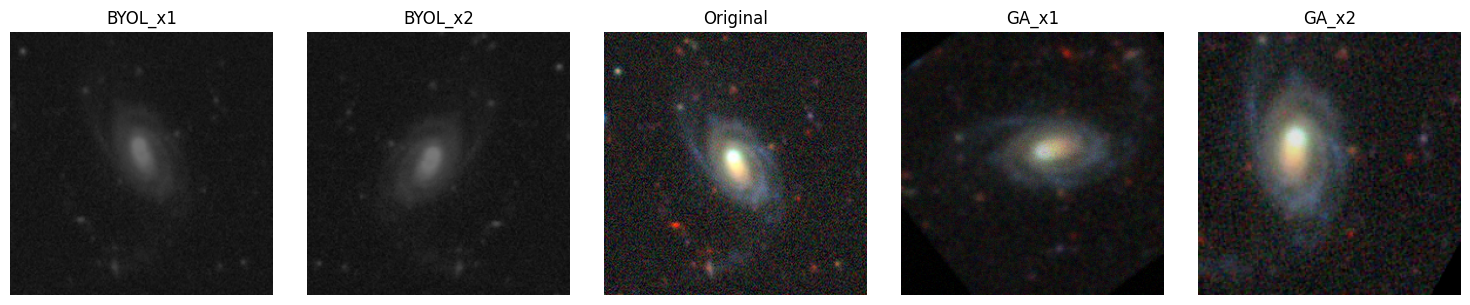

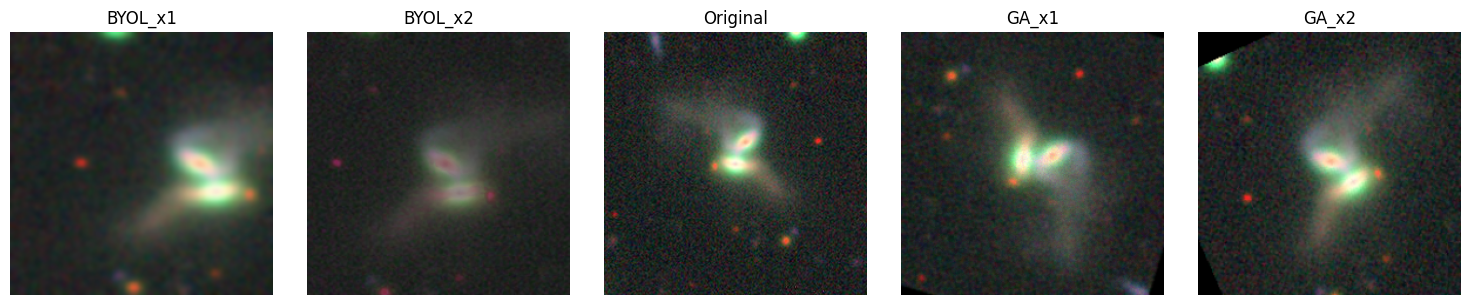

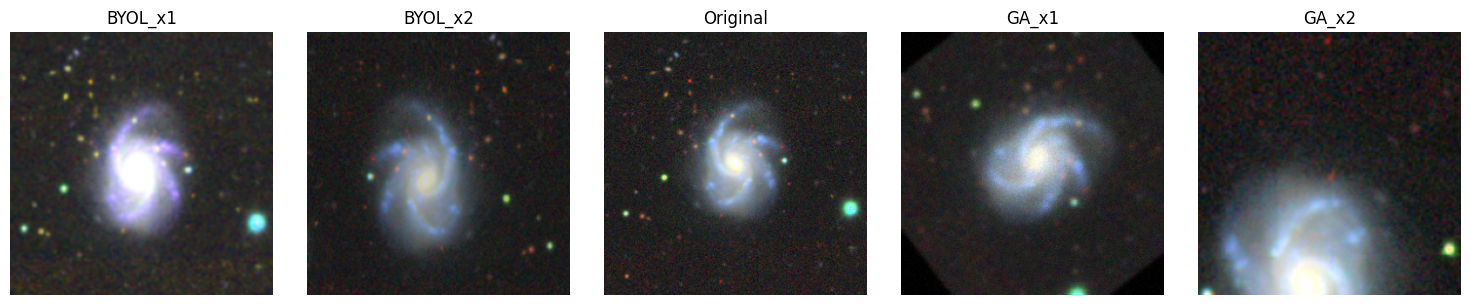

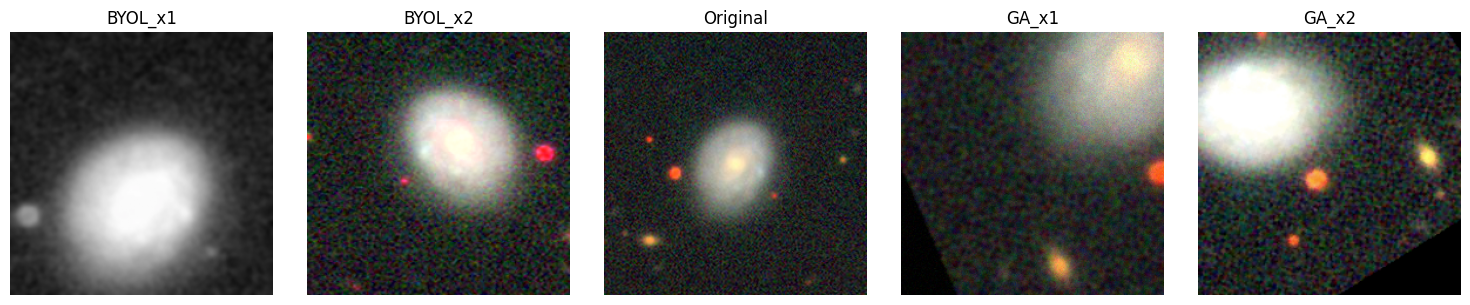

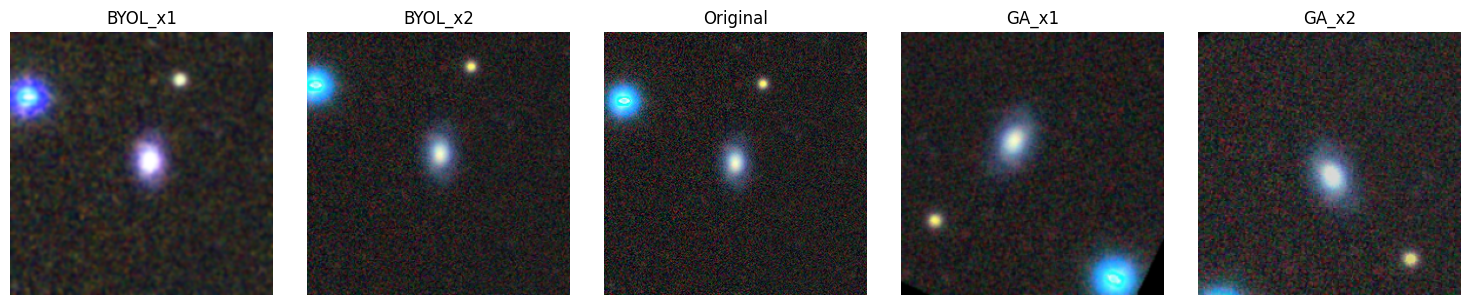

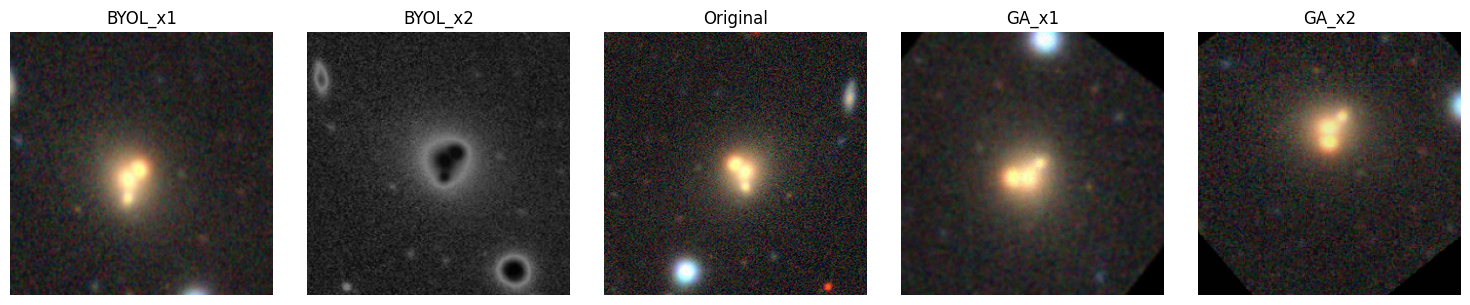

In [21]:
# build transforms
byol_t1, byol_t2 = build_byol_transforms(crop_min=0.2, img_size=224)
ga_t1, ga_t2     = build_galaxy_aware_transforms(crop_min=0.2, 
                                                 img_size=224, 
                                                 normalization="IN")  

class Denormalize:
    def __init__(self, mean, std):
        self.mean = torch.as_tensor(mean)[:, None, None]
        self.std  = torch.as_tensor(std)[:, None, None]
        
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        # move to the right device/dtype
        mean = self.mean.to(device=t.device, dtype=t.dtype)
        std  = self.std.to(device=t.device, dtype=t.dtype)
        return t * std + mean

denorm = Denormalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])  # calculated based on dataset

byol_denorm = Denormalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])  # ImageNet stats

# ---- visualize a few samples ----
def to_disp(t: torch.Tensor, denorm=denorm) -> np.ndarray:
    """Denormalize and convert CHW tensor to HWC uint8-like float image [0,1]."""
    t = denorm(t.clone())
    t = t.clamp(0, 1)
    return t.permute(1, 2, 0).cpu().numpy()

for img in ssl_ds["train"]["image"][:10]:  # PIL images
    byol_x1 = byol_t1(img)
    byol_x2 = byol_t2(img)
    ga_x1   = ga_t1(img)
    ga_x2   = ga_t2(img)
    
    imgs   = [byol_x1, byol_x2, img, ga_x1, ga_x2]
    titles = ["BYOL_x1", "BYOL_x2", "Original", "GA_x1", "GA_x2"]

    plt.figure(figsize=(15, 3))
    for i, (im, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, 5, i + 1)
        if isinstance(im, torch.Tensor):   # transformed (normalized) tensor
            im = to_disp(im, denorm=byol_denorm)
        else:                              # original PIL
            im = np.asarray(im)
        plt.imshow(im)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()